In [29]:
from google.colab import files
uploaded = files.upload()

Saving horizons_results.txt to horizons_results (3).txt


In [30]:
import pandas as pd
from io import StringIO

filename = list(uploaded.keys())[0]

with open(filename) as f:
    lines = f.readlines()

start = [i for i, line in enumerate(lines) if "$$SOE" in line][0] + 1
end = [i for i, line in enumerate(lines) if "$$EOE" in line][0]

data = lines[start:end]

temp = pd.read_csv(StringIO("".join(data)), header=None)

df = pd.DataFrame()
df["jd"] = temp[0]
df["date"] = temp[1]
df["x"] = pd.to_numeric(temp[2], errors="coerce")
df["y"] = pd.to_numeric(temp[3], errors="coerce")
df["z"] = pd.to_numeric(temp[4], errors="coerce")

In [31]:
AU = 149597870.7

df["x"] = df["x"] / AU
df["y"] = df["y"] / AU
df["z"] = df["z"] / AU


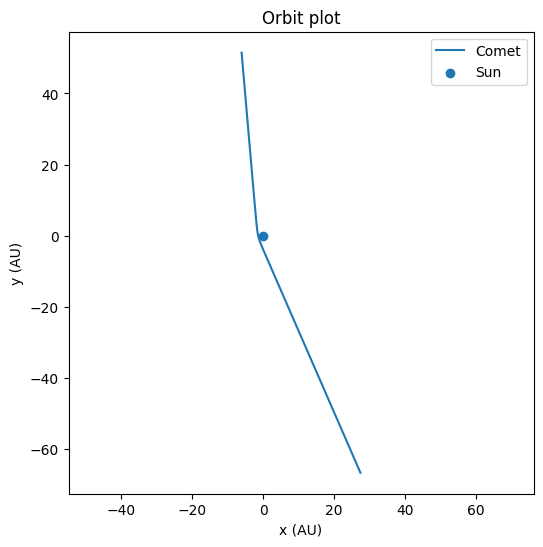

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(df["x"], df["y"], label="Comet")
plt.scatter(0, 0, label="Sun")

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Orbit plot")
plt.axis("equal")
plt.legend()
plt.show()

In [33]:
comet = df.copy()


In [34]:
from google.colab import files
uploaded = files.upload()

Saving horizons_results (1).txt to horizons_results (1) (1).txt


In [35]:
import pandas as pd
from io import StringIO

filename = list(uploaded.keys())[0]

with open(filename) as f:
    lines = f.readlines()

start = [i for i, line in enumerate(lines) if "$$SOE" in line][0] + 1
end = [i for i, line in enumerate(lines) if "$$EOE" in line][0]

data = lines[start:end]

temp = pd.read_csv(StringIO("".join(data)), header=None)

earth = pd.DataFrame()
earth["jd"] = temp[0]
earth["date"] = temp[1]
earth["x"] = pd.to_numeric(temp[2], errors="coerce")
earth["y"] = pd.to_numeric(temp[3], errors="coerce")
earth["z"] = pd.to_numeric(temp[4], errors="coerce")

AU = 149597870.7
earth["x"] = earth["x"] / AU
earth["y"] = earth["y"] / AU
earth["z"] = earth["z"] / AU

earth.head()

,jd,date,x,y,z
0,2458849.5,A.D. 2020-Jan-01 00:00:00.0000,-0.166346,0.969120,-0.000041
1,2458850.5,A.D. 2020-Jan-02 00:00:00.0000,-0.183557,0.965988,-0.000041
2,2458851.5,A.D. 2020-Jan-03 00:00:00.0000,-0.200711,0.962555,-0.000041
3,2458852.5,A.D. 2020-Jan-04 00:00:00.0000,-0.217800,0.958823,-0.000041
4,2458853.5,A.D. 2020-Jan-05 00:00:00.0000,-0.234820,0.954792,-0.000041


In [36]:
from google.colab import files
uploaded = files.upload()


Saving horizons_results (2).txt to horizons_results (2) (1).txt


In [37]:
import pandas as pd
from io import StringIO

filename = list(uploaded.keys())[0]

with open(filename) as f:
    lines = f.readlines()

start = [i for i, line in enumerate(lines) if "$$SOE" in line][0] + 1
end = [i for i, line in enumerate(lines) if "$$EOE" in line][0]

data = lines[start:end]

temp = pd.read_csv(StringIO("".join(data)), header=None)

jupiter = pd.DataFrame()
jupiter["jd"] = temp[0]
jupiter["date"] = temp[1]
jupiter["x"] = pd.to_numeric(temp[2], errors="coerce")
jupiter["y"] = pd.to_numeric(temp[3], errors="coerce")
jupiter["z"] = pd.to_numeric(temp[4], errors="coerce")

AU = 149597870.7
jupiter["x"] = jupiter["x"] / AU
jupiter["y"] = jupiter["y"] / AU
jupiter["z"] = jupiter["z"] / AU

jupiter.head()

,jd,date,x,y,z
0,2458849.5,A.D. 2020-Jan-01 00:00:00.0000,0.526147,-5.201023,0.009831
1,2458850.5,A.D. 2020-Jan-02 00:00:00.0000,0.533570,-5.199900,0.009660
2,2458851.5,A.D. 2020-Jan-03 00:00:00.0000,0.540992,-5.198768,0.009489
3,2458852.5,A.D. 2020-Jan-04 00:00:00.0000,0.548414,-5.197625,0.009318
4,2458853.5,A.D. 2020-Jan-05 00:00:00.0000,0.555835,-5.196471,0.009147


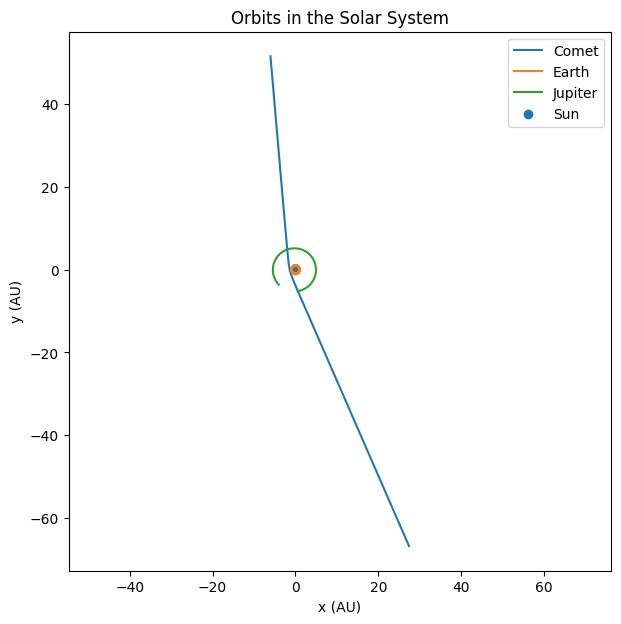

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.plot(comet["x"], comet["y"], label="Comet")
plt.plot(earth["x"], earth["y"], label="Earth")
plt.plot(jupiter["x"], jupiter["y"], label="Jupiter")
plt.scatter(0, 0, label="Sun")

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Orbits in the Solar System")
plt.axis("equal")
plt.legend()
plt.show()


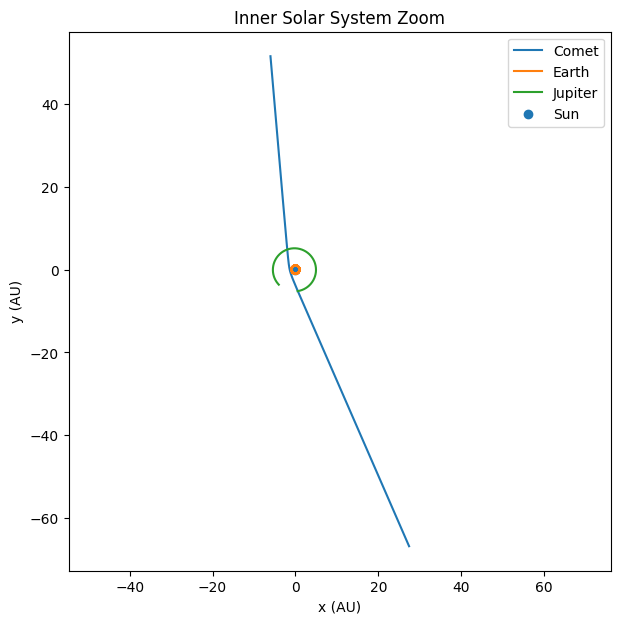

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.plot(comet["x"], comet["y"], label="Comet")
plt.plot(earth["x"], earth["y"], label="Earth")
plt.plot(jupiter["x"], jupiter["y"], label="Jupiter")
plt.scatter(0, 0, label="Sun")

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Inner Solar System Zoom")
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.axis("equal")
plt.legend()
plt.show()

In [40]:
import numpy as np
from scipy.interpolate import UnivariateSpline

t = np.arange(len(comet))

spline_x = UnivariateSpline(t, comet['x'], s=5)
spline_y = UnivariateSpline(t, comet['y'], s=5)


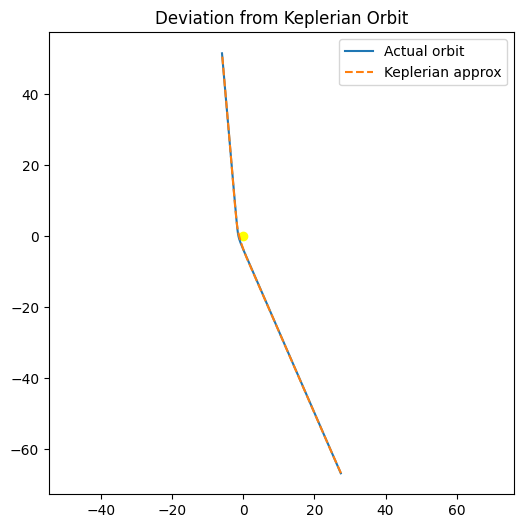

In [41]:
plt.figure(figsize=(6,6))

plt.plot(comet['x'], comet['y'], label="Actual orbit")
plt.plot(spline_x(t), spline_y(t), '--', label="Keplerian approx")

plt.scatter(0,0, color='yellow')

plt.legend()
plt.title("Deviation from Keplerian Orbit")
plt.axis('equal')
plt.show()

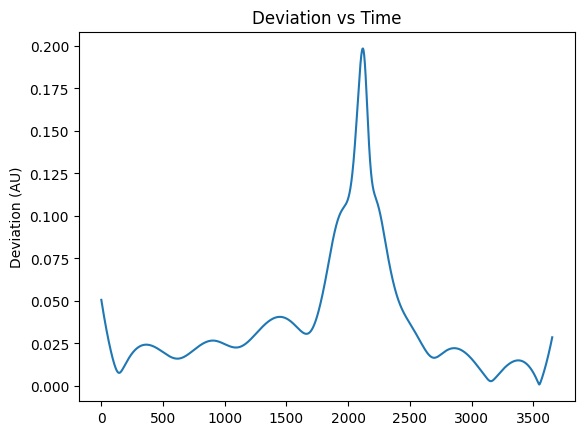

In [42]:
deviation = np.sqrt(
    (comet['x'] - spline_x(t))**2 +
    (comet['y'] - spline_y(t))**2
)

plt.plot(deviation)
plt.title("Deviation vs Time")
plt.ylabel("Deviation (AU)")
plt.show()

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make copies so original data stays untouched
comet = comet.copy()
earth = earth.copy()
jupiter = jupiter.copy()

# Convert date columns to datetime
comet["date"] = pd.to_datetime(comet["date"].str.replace("A.D. ", "", regex=False))
earth["date"] = pd.to_datetime(earth["date"].str.replace("A.D. ", "", regex=False))
jupiter["date"] = pd.to_datetime(jupiter["date"].str.replace("A.D. ", "", regex=False))

# Keep only needed columns
comet = comet[["date", "x", "y", "z"]]
earth = earth[["date", "x", "y", "z"]]
jupiter = jupiter[["date", "x", "y", "z"]]

# Merge by date
df = comet.merge(earth, on="date", suffixes=("_comet", "_earth"))
df = df.merge(jupiter, on="date")
df = df.rename(columns={
    "x": "x_jupiter",
    "y": "y_jupiter",
    "z": "z_jupiter"
})

df.head()

,date,x_comet,y_comet,z_comet,x_earth,y_earth,z_earth,x_jupiter,y_jupiter,z_jupiter
0,2020-01-01,27.413389,-66.737350,3.067139,-0.166346,0.969120,-0.000041,0.526147,-5.201023,0.009831
1,2020-01-02,27.399958,-66.706582,3.065766,-0.183557,0.965988,-0.000041,0.533570,-5.199900,0.009660
2,2020-01-03,27.386527,-66.675813,3.064394,-0.200711,0.962555,-0.000041,0.540992,-5.198768,0.009489
3,2020-01-04,27.373096,-66.645045,3.063021,-0.217800,0.958823,-0.000041,0.548414,-5.197625,0.009318
4,2020-01-05,27.359664,-66.614276,3.061649,-0.234820,0.954792,-0.000041,0.555835,-5.196471,0.009147


In [44]:
#Distance from comet to Sun
df["dist_sun"] = np.sqrt(
    df["x_comet"]**2 + df["y_comet"]**2 + df["z_comet"]**2
)

# Distance from comet to Earth
df["dist_earth"] = np.sqrt(
    (df["x_comet"] - df["x_earth"])**2 +
    (df["y_comet"] - df["y_earth"])**2 +
    (df["z_comet"] - df["z_earth"])**2
)

# Distance from comet to Jupiter
df["dist_jupiter"] = np.sqrt(
    (df["x_comet"] - df["x_jupiter"])**2 +
    (df["y_comet"] - df["y_jupiter"])**2 +
    (df["z_comet"] - df["z_jupiter"])**2
)

df[["date", "dist_sun", "dist_earth", "dist_jupiter"]].head()


,date,dist_sun,dist_earth,dist_jupiter
0,2020-01-01,72.213400,73.172505,67.223437
1,2020-01-02,72.179808,73.142506,67.187904
2,2020-01-03,72.146216,73.112210,67.152381
3,2020-01-04,72.112624,73.081617,67.116869
4,2020-01-05,72.079031,73.050726,67.081368


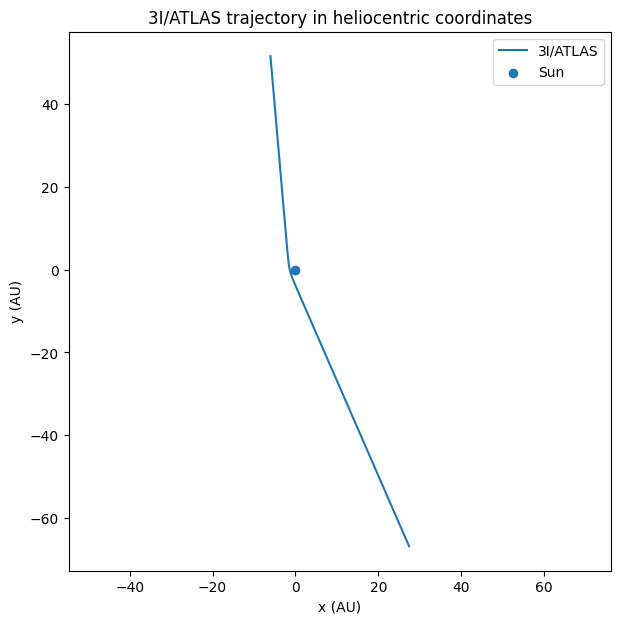

In [45]:
plt.figure(figsize=(7,7))
plt.plot(df["x_comet"], df["y_comet"], label="3I/ATLAS")
plt.scatter(0, 0, label="Sun")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("3I/ATLAS trajectory in heliocentric coordinates")
plt.axis("equal")
plt.legend()
plt.show()


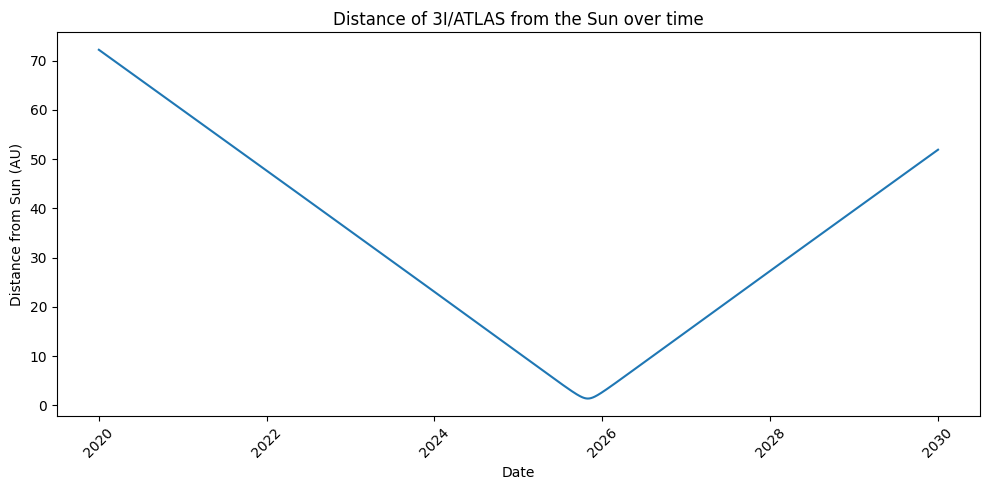

In [46]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["dist_sun"])
plt.xlabel("Date")
plt.ylabel("Distance from Sun (AU)")
plt.title("Distance of 3I/ATLAS from the Sun over time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


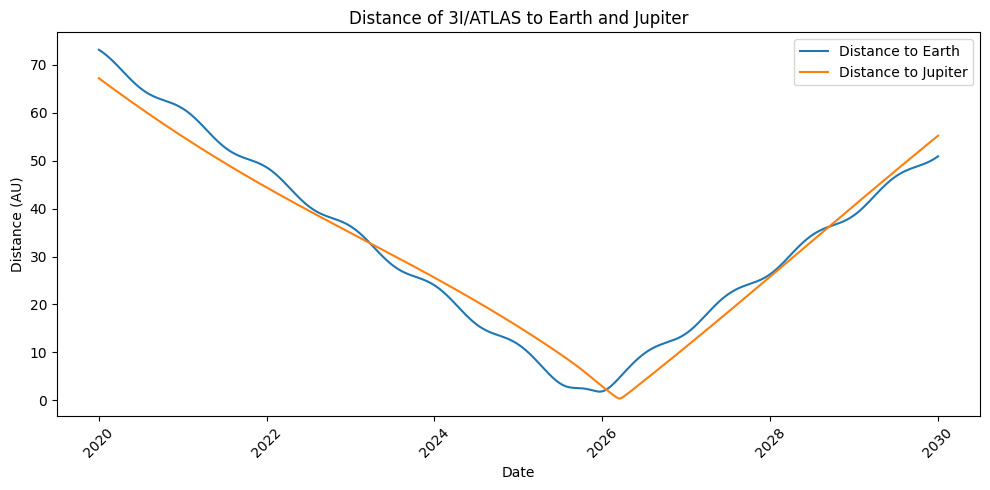

In [47]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["dist_earth"], label="Distance to Earth")
plt.plot(df["date"], df["dist_jupiter"], label="Distance to Jupiter")
plt.xlabel("Date")
plt.ylabel("Distance (AU)")
plt.title("Distance of 3I/ATLAS to Earth and Jupiter")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Parameter along path
t = np.linspace(0, 1, len(df))

# Start and end points
x0, y0, z0 = df.loc[df.index[0], ["x_comet", "y_comet", "z_comet"]]
x1, y1, z1 = df.loc[df.index[-1], ["x_comet", "y_comet", "z_comet"]]

# Reference straight line
df["x_ref"] = x0 + t * (x1 - x0)
df["y_ref"] = y0 + t * (y1 - y0)
df["z_ref"] = z0 + t * (z1 - z0)

# Deviation
df["deviation"] = np.sqrt(
    (df["x_comet"] - df["x_ref"])**2 +
    (df["y_comet"] - df["y_ref"])**2 +
    (df["z_comet"] - df["z_ref"])**2
)

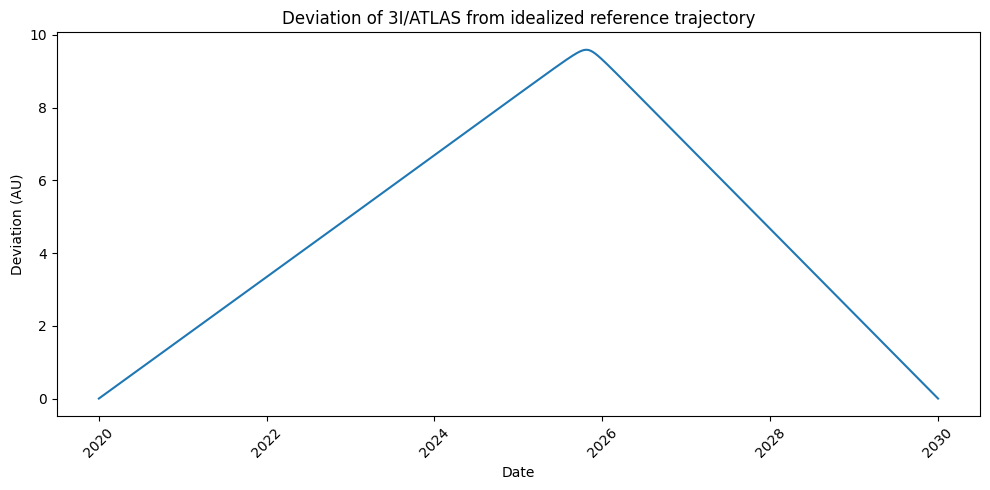

In [49]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["deviation"])
plt.xlabel("Date")
plt.ylabel("Deviation (AU)")
plt.title("Deviation of 3I/ATLAS from idealized reference trajectory")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
max_dev_row = df.loc[df["deviation"].idxmax()]
print("Maximum deviation occurs on:", max_dev_row["date"])
print("Maximum deviation (AU):", max_dev_row["deviation"])
print("Distance to Earth at that time (AU):", max_dev_row["dist_earth"])
print("Distance to Jupiter at that time (AU):", max_dev_row["dist_jupiter"])
print("Distance to Sun at that time (AU):", max_dev_row["dist_sun"])

Maximum deviation occurs on: 2025-10-23 00:00:00
Maximum deviation (AU): 9.589343094271326
Distance to Earth at that time (AU): 2.368474008881285
Distance to Jupiter at that time (AU): 5.62672141334878
Distance to Sun at that time (AU): 1.3770278651809225


In [51]:
closest_earth = df.loc[df["dist_earth"].idxmin()]
closest_jupiter = df.loc[df["dist_jupiter"].idxmin()]

print("Closest approach to Earth:")
print(closest_earth["date"], " distance =", closest_earth["dist_earth"], "AU")

print("\nClosest approach to Jupiter:")
print(closest_jupiter["date"], " distance =", closest_jupiter["dist_jupiter"], "AU")

Closest approach to Earth:
2025-12-19 00:00:00  distance = 1.7977519159393784 AU

Closest approach to Jupiter:
2026-03-17 00:00:00  distance = 0.35879724760235154 AU


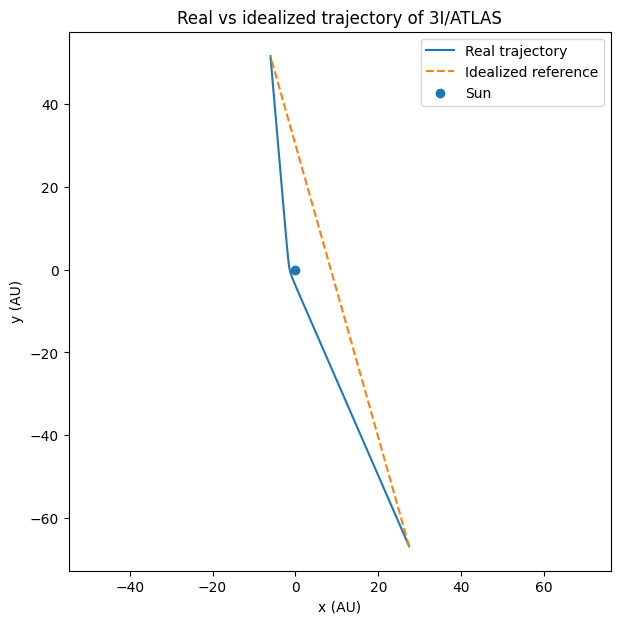

In [52]:
plt.figure(figsize=(7,7))
plt.plot(df["x_comet"], df["y_comet"], label="Real trajectory")
plt.plot(df["x_ref"], df["y_ref"], "--", label="Idealized reference")
plt.scatter(0, 0, label="Sun")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Real vs idealized trajectory of 3I/ATLAS")
plt.axis("equal")
plt.legend()
plt.show()